In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [3]:
df['Attrition'] = df['Attrition'].fillna(df['Attrition'].mode()[0])

In [4]:
df['Attrition'] = df['Attrition'].str.strip()

In [5]:
df['Attrition'] = df['Attrition'].map({'Yes':1,'No':0})

In [6]:
df.drop(['EmployeeNumber','EmployeeCount','StandardHours'], axis=1, inplace=True)

In [7]:
df = pd.get_dummies(df, drop_first=True)

In [8]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
y_pred = rf.predict(X_test)

In [12]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8741496598639455

Confusion Matrix:
[[253   2]
 [ 35   4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       255
           1       0.67      0.10      0.18        39

    accuracy                           0.87       294
   macro avg       0.77      0.55      0.55       294
weighted avg       0.85      0.87      0.83       294



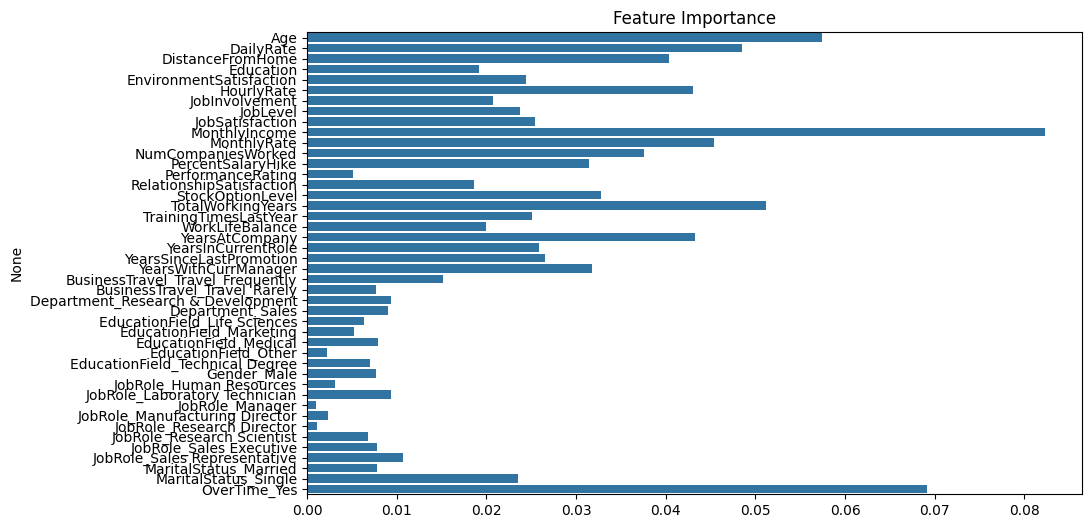

In [13]:
importance = rf.feature_importances_

plt.figure(figsize=(10,6))
sns.barplot(x=importance, y=X.columns)

plt.title("Feature Importance")
plt.show()